In [1]:
# importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import gudhi
from gudhi import RipsComplex
from gudhi.representations import PersistenceImage

In [2]:
def k_means_clustering(data, cluster_size):
    kmeans = KMeans(n_clusters=cluster_size, random_state=42).fit(data)
    centroids = kmeans.cluster_centers_
    rep_id = pairwise_distances_argmin(centroids, data)
    clustering = data[rep_id]
    return clustering

In [3]:
data = pd.read_csv("star_classification.csv")

In [105]:
# importing the data
data = pd.read_csv("star_classification.csv")

# scanning for weird values and dropping that
data = data.replace(-9999,np.NaN) 
data = data.dropna()

# adding a label dictionary to attach each class of object to a number
label_dict = {"GALAXY":0,"QSO":1,"STAR":2}

# scaling and selecting the features we want to use in the model training
scaler = StandardScaler()
feature_list = ["u","g","r","i","z","redshift","alpha","delta","MJD"]
data[feature_list] = scaler.fit_transform(data[feature_list])
threshold = 4
data = data[~ (data[feature_list]**2 > threshold**2).any(axis=1)]
# data["redshift"] = 1/(1+data["redshift"])


# setting X and y for model training
X = data[feature_list].to_numpy()
y = data["class"].replace(label_dict).to_numpy()

/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_70213/4160878387.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = data["class"].replace(label_dict).to_numpy()


In [106]:
# splitting into training, testing, and validation sets
train_features, test_features, train_targets, test_targets = train_test_split(
                                                X, 
                                                y, 
                                                test_size=0.1, 
                                                random_state=2)


validation_features, test_features, validation_targets, test_targets = train_test_split(
                                                    test_features, 
                                                    test_targets, 
                                                    test_size=0.5, 
                                                    random_state=2)

The fully connected network baseline will utilize the fully connected block we have in our CNN model

In [107]:
import torch.nn as nn

class simpleFCN(nn.Module):
    def __init__(self, input_dim, num_of_classes, hidden_layer_size):

        super(simpleFCN, self).__init__()
        # The fully connected block 
        # three layers with linear activation and dropout for regularization
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, num_of_classes)
        )

    def forward(self, x):
        #x = nn.functional.relu((self.fc_layers(x)))
        x = self.fc_layers(x)
        return x

In [108]:
model = simpleFCN(
    input_dim = 9, 
    num_of_classes = 3, 
    hidden_layer_size = 20,
    
)

learning_rate = 0.01
epochs  = 15

loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

In [109]:
train_loss_list = []
validation_accuracy_list = np.zeros((epochs,))

In [110]:
train_inputs = torch.from_numpy(train_features).float()
train_targets = torch.from_numpy(train_targets.astype(int))

validation_inputs = torch.from_numpy(validation_features).float()
validation_targets = torch.from_numpy(validation_targets.astype(int))

testing_inputs = torch.from_numpy(test_features).float()
testing_targets = torch.from_numpy(test_targets.astype(int)) 

In [111]:
batchsize = 1000

# Use torch.split() function to split the training inputs/targets into mini-batches
train_batches_features = torch.split(train_inputs, batchsize)
train_batches_targets = torch.split(train_targets, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num = len(train_batches_features)

In [112]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar


for epoch in tqdm.trange(epochs):
    model.train() # Set the model to training mode
    
    for k in range(batch_split_num):
    
        optimizer.zero_grad()
            
        train_batch_outputs = model(train_batches_features[k])

        loss = loss_func(train_batch_outputs, train_batches_targets[k])

        train_loss_list.append(loss.item())

        loss.backward()

        optimizer.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    with torch.no_grad():
        model.eval() # Set the model to evaluation mode to turn off dropout layers

        validation_outputs = model(validation_inputs)

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor)
        
        validation_accuracy = np.round(correct.mean().numpy() * 100, 2)
        
        print("Epoch: "+ str(epoch), 
              "Validation Accuracy: " + str(validation_accuracy) + '%', flush=True)
        
        
        

        validation_accuracy_list[epoch] = correct.mean()


  0%|                                                    | 0/15 [00:00<?, ?it/s]

Epoch: 0 Validation Accuracy: 92.68%
Epoch: 1 Validation Accuracy: 95.01%


 13%|█████▊                                      | 2/15 [00:00<00:01, 11.91it/s]

Epoch: 2 Validation Accuracy: 95.19%
Epoch: 3 Validation Accuracy: 95.11%


 27%|███████████▋                                | 4/15 [00:00<00:00, 12.26it/s]

...

 80%|██████████████████████████████████▍        | 12/15 [00:00<00:00, 12.21it/s]

Epoch: 12 Validation Accuracy: 95.63%
Epoch: 13 Validation Accuracy: 95.53%


 93%|████████████████████████████████████████▏  | 14/15 [00:01<00:00, 11.47it/s]

Epoch: 14 Validation Accuracy: 95.7%


100%|███████████████████████████████████████████| 15/15 [00:01<00:00, 11.84it/s]


Text(0, 0.5, 'validation accuracy')

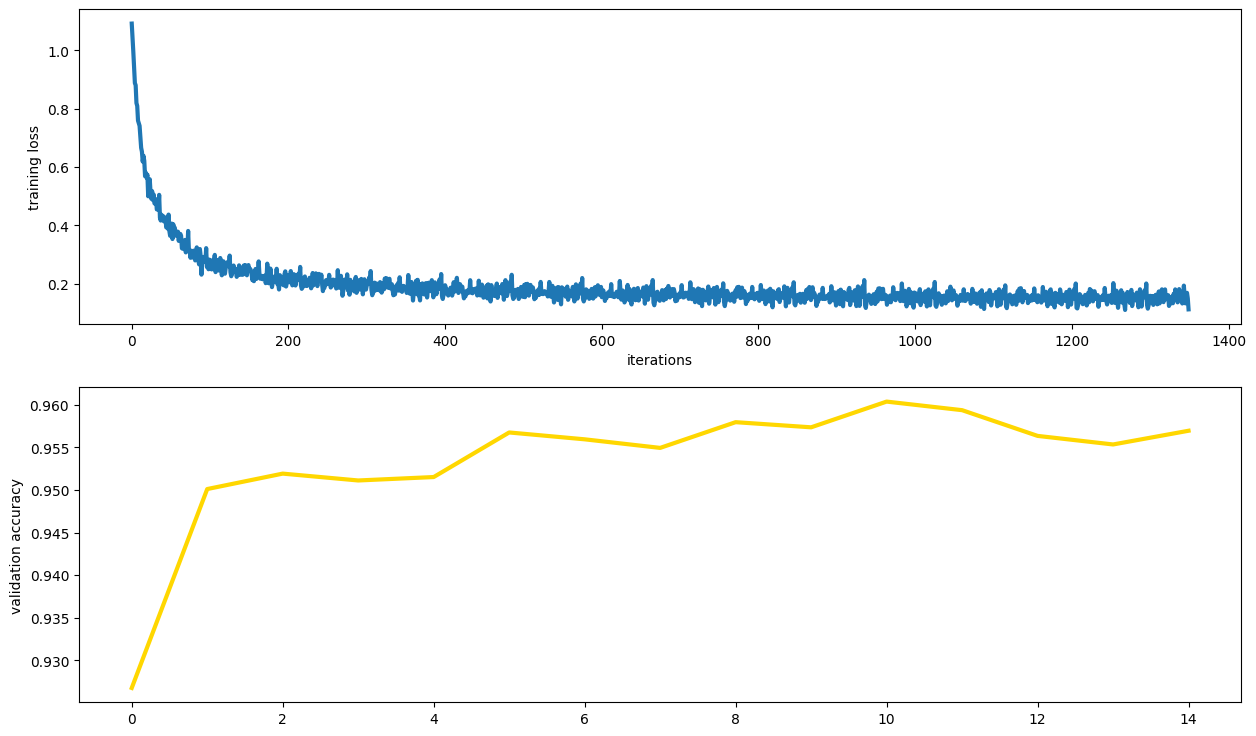

In [113]:
plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")


plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")

Testing Accuracy: 0.95131767


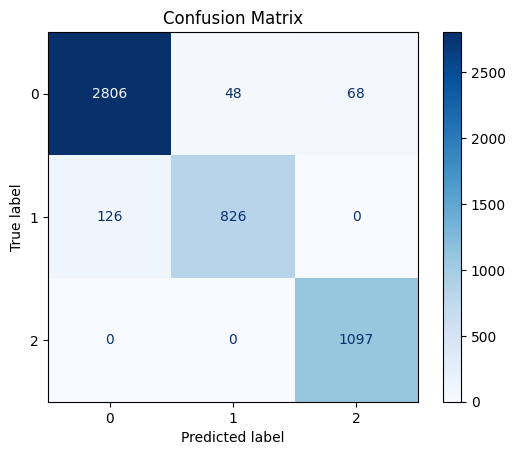

In [114]:
# Compute the testing accuracy 

with torch.no_grad():
    model.eval() # Set the model to evaluation mode to turn off dropout layers
    
    y_pred_test = model(testing_inputs)
     
    correct = (torch.argmax(y_pred_test, dim=1) == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(testing_targets, torch.argmax(y_pred_test, dim=1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [94]:
# galaxy accuracy
galaxy_mask = np.where(testing_targets==0)
galaxies_correct = np.mean((testing_targets[galaxy_mask]==torch.argmax(y_pred_test[galaxy_mask], dim=1)).numpy())

# quasar accuracy
quasar_mask = np.where(testing_targets==1)
quasar_correct = np.mean((testing_targets[quasar_mask]==torch.argmax(y_pred_test[quasar_mask], dim=1)).numpy())

# star accuracy
star_mask = np.where(testing_targets==2)
star_correct = np.mean((testing_targets[star_mask]==torch.argmax(y_pred_test[star_mask], dim=1)).numpy())

print(f'Galaxy accuracy: {(galaxies_correct*100):.2f}%')
print(f'Quasar accuracy: {(quasar_correct*100):.2f}%')
print(f'Star accuracy: {(star_correct*100):.2f}%')

Galaxy accuracy: 96.13%
Quasar accuracy: 86.66%
Star accuracy: 100.00%
